In [1]:
!pip install yfinance

In [2]:
import yfinance as yf
import pandas as pd

tickers = ["THYAO.IS", "GARAN.IS", "ASELS.IS", "EREGL.IS"]

data = yf.download(tickers, start="2023-01-01", end="2024-12-31")

close_prices = data["Close"]

close_prices.head()

/tmp/ipykernel_12798/2510787412.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2023-01-01", end="2024-12-31")
[*********************100%***********************]  4 of 4 completed


Ticker,ASELS.IS,EREGL.IS,GARAN.IS,THYAO.IS
Date,,,,
2023-01-02,32.145420,20.933308,26.237032,143.406601
2023-01-03,34.384655,20.669073,25.551544,143.992722
2023-01-04,32.419106,21.001812,25.705778,141.159760
2023-01-05,30.926285,20.424412,24.780371,138.522171
2023-01-06,31.299490,20.375479,24.180569,139.206009


In [3]:
returns = close_prices.pct_change()
returns.head()

/tmp/ipykernel_12798/3283322045.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = close_prices.pct_change()


Ticker,ASELS.IS,EREGL.IS,GARAN.IS,THYAO.IS
Date,,,,
2023-01-02,NaN,NaN,NaN,NaN
2023-01-03,0.069660,-0.012623,-0.026127,0.004087
2023-01-04,-0.057164,0.016098,0.006036,-0.019674
2023-01-05,-0.046048,-0.027493,-0.036000,-0.018685
2023-01-06,0.012068,-0.002396,-0.024205,0.004937


In [4]:
volatility = returns.std()
mean_returns = returns.mean()

print("Volatility (Risk):")
print(volatility)

print("\nMean Return (Getiri):")
print(mean_returns)

Volatility (Risk):
Ticker
ASELS.IS    0.030008
EREGL.IS    0.025252
GARAN.IS    0.031210
THYAO.IS    0.027384
dtype: float64

Mean Return (Getiri):
Ticker
ASELS.IS    0.002097
EREGL.IS    0.000621
GARAN.IS    0.003572
THYAO.IS    0.001682
dtype: float64


/tmp/ipykernel_12798/578208946.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(txt, (volatility[i], mean_returns[i]))


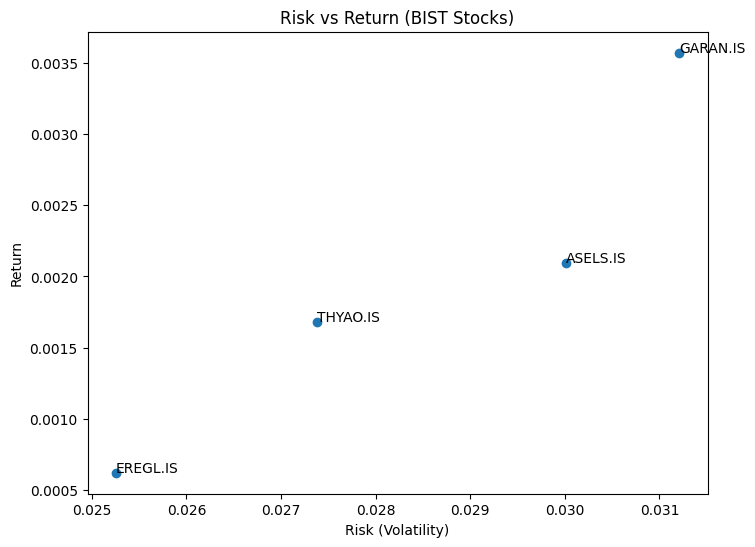

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(volatility, mean_returns)

for i, txt in enumerate(mean_returns.index):
    plt.annotate(txt, (volatility[i], mean_returns[i]))

plt.xlabel("Risk (Volatility)")
plt.ylabel("Return")
plt.title("Risk vs Return (BIST Stocks)")

plt.show()

In [6]:
sharpe = mean_returns / volatility
print(sharpe.sort_values(ascending=False))

Ticker
GARAN.IS    0.114437
ASELS.IS    0.069894
THYAO.IS    0.061431
EREGL.IS    0.024576
dtype: float64


In [7]:
best_stock = sharpe.idxmax()
print("En iyi hisse:", best_stock)

En iyi hisse: GARAN.IS


In [8]:
initial_investment = 10000

# toplam getiri hesapla
cumulative_returns = (1 + returns).cumprod()

# yatırım değeri
portfolio = cumulative_returns * initial_investment

portfolio.tail()

Ticker,ASELS.IS,EREGL.IS,GARAN.IS,THYAO.IS
Date,,,,
2024-12-24,22571.662148,11764.614606,46495.152104,19448.229705
2024-12-25,22991.094172,11859.260824,48994.500559,19635.559429
2024-12-26,23115.370151,11726.755208,48149.129663,19754.766157
2024-12-27,22975.557894,11802.473093,47781.580387,19805.858403
2024-12-30,22742.539840,11641.573156,46384.885576,19226.840613


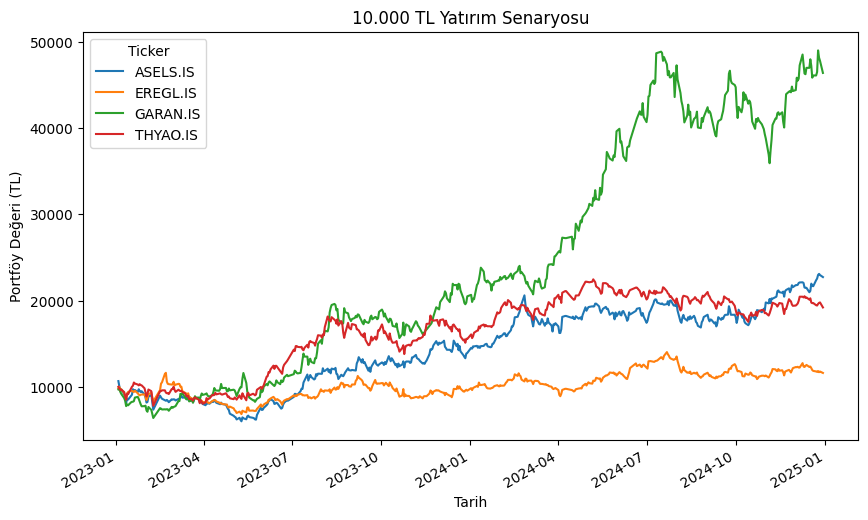

In [9]:
import matplotlib.pyplot as plt

portfolio.plot(figsize=(10,6))

plt.title("10.000 TL Yatırım Senaryosu")
plt.xlabel("Tarih")
plt.ylabel("Portföy Değeri (TL)")

plt.show()

<Axes: title={'center': 'Portföy Performansı'}, xlabel='Date'>

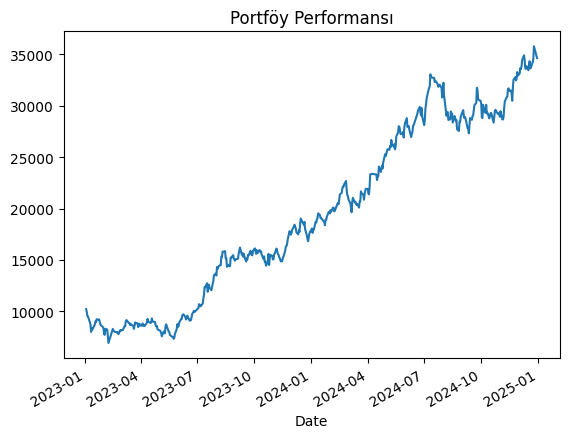

In [10]:
weights = [0.5, 0.5]  # %50 - %50

portfolio_return = (returns["GARAN.IS"] * weights[0] +
                    returns["ASELS.IS"] * weights[1])

portfolio_cum = (1 + portfolio_return).cumprod() * 10000

portfolio_cum.plot(title="Portföy Performansı")

In [11]:
import numpy as np

results = []

for w in np.arange(0, 1.1, 0.1):
    portfolio_return = (returns["GARAN.IS"] * w +
                        returns["ASELS.IS"] * (1 - w))

    mean = portfolio_return.mean()
    risk = portfolio_return.std()
    sharpe = mean / risk

    results.append((w, mean, risk, sharpe))

import pandas as pd
df_results = pd.DataFrame(results, columns=["GARAN_weight", "Return", "Risk", "Sharpe"])

df_results.sort_values(by="Sharpe", ascending=False)

,GARAN_weight,Return,Risk,Sharpe
8,0.8,0.003277,0.028125,0.116505
9,0.9,0.003424,0.029530,0.115955
7,0.7,0.003129,0.027038,0.115737
10,1.0,0.003572,0.031210,0.114437
6,0.6,0.002982,0.026309,0.113343
5,0.5,0.002834,0.025967,0.109158
4,0.4,0.002687,0.026028,0.103239
3,0.3,0.002540,0.026488,0.095878
2,0.2,0.002392,0.027329,0.087534
1,0.1,0.002245,0.028516,0.078721


<Axes: title={'center': 'Sharpe Ratio vs Portfolio Weight'}, xlabel='GARAN_weight'>

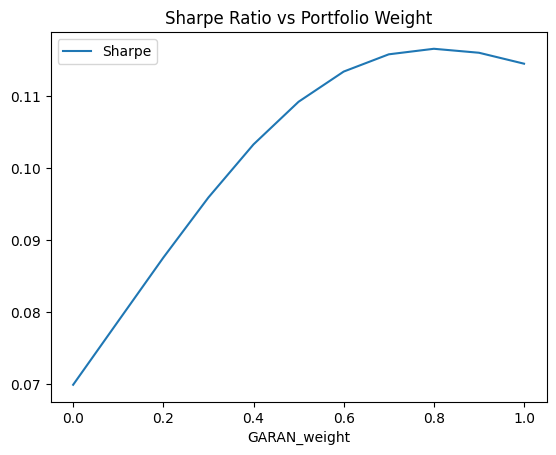

In [12]:
df_results.plot(x="GARAN_weight", y="Sharpe", title="Sharpe Ratio vs Portfolio Weight")

In [13]:
best = df_results.sort_values(by="Sharpe", ascending=False).iloc[0]
print(best)

GARAN_weight    0.800000
Return          0.003277
Risk            0.028125
Sharpe          0.116505
Name: 8, dtype: float64
